#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import psutil
from functools import partial
from joblib import Parallel, delayed 
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [2]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [3]:
type(analysis_config)
analysis_config
stage_names = analysis_config.task_phase_names
stage_cols =  stage_names
stage_names


['Early_IA_Error',
 'Early_IA_Correct',
 'Late_IA',
 'Early_RS_Error',
 'Early_RS_Correct',
 'Late_RS']

#### Define dataset methods

In [4]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#make analysis folder 
hour_str = datetime.now().strftime("%H")

storage_folder_name = root_dir / Path(f"processed_{data_type_used}")
print(storage_folder_name)
storage_folder_name.mkdir(parents=True, exist_ok=True)


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [5]:
## Matlab file handling functions:
import h5py

def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES:")

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [6]:
#get all dataset names
#verify you are using the correct number of dataset 
source_dataset_location = Path(r"C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects")
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match expected"

Found 35 files in C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_obje

In [7]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(failed_files)

Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 136 cells × 150415 frames
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 168 cells × 97940 frames
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 157 cells × 108794 frames
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 160 cells × 191533 frames
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 145 cells × 108651 frames
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 147 cells × 128277 frames
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 183 cells × 153831 frames
Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  13_4_WT_RS2: 171 cells × 106245 frames
Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  13_5_HET_RS1: 120 cells × 229350 frames
Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  13_5_HET_RS2: 125 cells × 141283 frames
Loading file 10/35: 13_5_HET_RS3_dataset_object.mat
  13_5_HET_RS3: 131 cel

#### study object info

In [8]:
obj.keys()

dict_keys(['name', 'geno', 'session', 'geno_day', 'raster', 'deduplicated', 'good_cells', 'labels', 'spatial_weights', 'temporal_weights', 'user_labels', 'subject_name'])

In [9]:
len(obj['user_labels'])

329

In [10]:
for obj in loaded_objects:
    print(f"  {obj['name']}: Good cells: {len(obj['good_cells'])}, raster shape: {obj['raster'].shape[0]}  × {obj['raster'].shape[1]}")

  10_3_HET_RS1: Good cells: 136, raster shape: 136  × 150415
  10_3_HET_RS2: Good cells: 168, raster shape: 168  × 97940
  10_3_HET_RS3: Good cells: 157, raster shape: 157  × 108794
  13_3_HET_RS1: Good cells: 160, raster shape: 160  × 191533
  13_3_HET_RS2: Good cells: 145, raster shape: 145  × 108651
  13_3_HET_RS3: Good cells: 147, raster shape: 147  × 128277
  13_4_WT_RS1: Good cells: 183, raster shape: 183  × 153831
  13_4_WT_RS2: Good cells: 171, raster shape: 171  × 106245
  13_5_HET_RS1: Good cells: 120, raster shape: 120  × 229350
  13_5_HET_RS2: Good cells: 125, raster shape: 125  × 141283
  13_5_HET_RS3: Good cells: 131, raster shape: 131  × 96995
  13_6_WT_RS1: Good cells: 247, raster shape: 247  × 206081
  13_6_WT_RS2: Good cells: 246, raster shape: 246  × 145514
  13_8_HET_RS1: Good cells: 207, raster shape: 207  × 124098
  13_8_HET_RS2: Good cells: 206, raster shape: 206  × 111694
  13_8_HET_RS3: Good cells: 244, raster shape: 244  × 126723
  14_2_WT_RS1: Good cells: 186

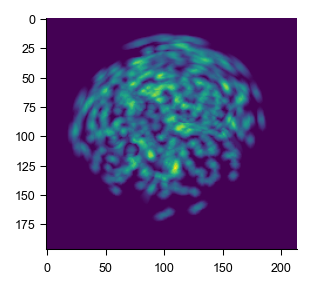

In [11]:
fig,ax = plt.subplots(figsize = (3,2))
plt.imshow(np.mean(obj['spatial_weights'], axis=0))

####  Get post-outcome time-series directly

In [12]:
canon_timeseries_path = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv")
canon_timeseries = pd.read_csv(canon_timeseries_path)
canon_timeseries.tail()

C:\Users\13car\AppData\Local\Temp\ipykernel_14068\1035457358.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  canon_timeseries = pd.read_csv(canon_timeseries_path)


,task_phase_vec,IA_RS_vec,corr_err_vec,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,-f_10,-f_9,-f_8,-f_7,-f_6,-f_5,-f_4,-f_3,-f_2,-f_1
191416,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
191417,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
191418,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
191419,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
191420,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:

canon_tseries_metadata_col = [c for c in canon_timeseries.columns if "f_" not in c]
canon_timeseries['unique_ID'] = canon_timeseries['name'].astype(str) + "-" + canon_timeseries['neuron_ID'].astype(str)
canon_timeseries

,task_phase_vec,IA_RS_vec,corr_err_vec,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,-f_9,-f_8,-f_7,-f_6,-f_5,-f_4,-f_3,-f_2,-f_1,unique_ID
0,Early_IA_Correct,IA,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10_3_HET_RS1-1
1,Early_IA_Correct,IA,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10_3_HET_RS1-2
2,Early_IA_Correct,IA,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10_3_HET_RS1-3
3,Early_IA_Correct,IA,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10_3_HET_RS1-4
4,Early_IA_Correct,IA,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191416,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9_3_HET_RS3-211
191417,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9_3_HET_RS3-212
191418,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9_3_HET_RS3-213
191419,Late_RS,RS,Correct,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9_3_HET_RS3-214


#### Import canon TACO

In [15]:

#original taco from 12/10/24 with 1k shuffles
canon_taco = data_dir / Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\main_datasets_complexTACO- neurons_activity by task phase_10-Dec-2024.xls")
canon_taco = pd.read_excel(canon_taco,na_values = -99).replace(-99, np.nan)

#get metadata
frame_cols = [c for c in canon_taco.columns if 'f_' in c]
non_frame_cols = [c for c in canon_taco.columns if 'f_' not in c]
post_stage_names = ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA',
 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct','post_outcome_Late_RS']
print(non_frame_cols)
print(f" Unique canon cells: {canon_taco.groupby(by = 'name')['neuron_ID'].nunique().sum()}")

#get canon/original post taco
canon_post_taco = canon_taco[ post_stage_names +['name','geno_day','geno','neuron_ID']].copy()
canon_post_taco.rename({old:old.replace("post_outcome_","") for old in post_stage_names},axis=1, inplace=True)
canon_post_taco['unique_ID'] = canon_post_taco['name'].str.cat(canon_post_taco['neuron_ID'].astype(str), sep="-")
canon_post_taco

['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'baseline_sig_cells', 'name', 'geno_day', 'geno', 'neuron_ID', 'Var1_1', 'Var1_2', 'Var1_3', 'Var1_4', 'Var1_5', 'Var1_6']
 Unique canon cells: 5961


,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,unique_ID
0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,10_3_HET_RS1-1
1,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,10_3_HET_RS1-2
2,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3,10_3_HET_RS1-3
3,0.0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4,10_3_HET_RS1-4
4,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...
5956,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211,9_3_HET_RS3-211
5957,1.0,1,0,0,0,0,9_3_HET_RS3,HET RS3,HET,212,9_3_HET_RS3-212
5958,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213,9_3_HET_RS3-213
5959,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,214,9_3_HET_RS3-214


#### test loading

### Extract and Transform Matlab Objects into stage-labeled dataframes

#### E- dataset objs to dataframes, T- add task stage cols

In [16]:
def dataset_obj_to_df(dataset_obj):
    # Create DataFrame from raster (cells × frames)
    print(f"Processing {dataset_obj['name']}: {dataset_obj['raster'].nbytes} bytes")
    #setup dataset df 
    raster_df = pd.DataFrame(
        dataset_obj['raster'].T,
        index=[f'frame_{i}' for i in range(dataset_obj['raster'].shape[1])],
        columns = [f'cell_{i+1}' for i in range(dataset_obj['raster'].shape[0])],
        dtype = 'Sparse[int]')
            #add labels
    raster_df['labels'] = dataset_obj['labels']
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    
    return raster_df
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0])
print(test_df.info())
test_df.tail(3)

Processing 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 140 entries, cell_1 to session
dtypes: Sparse[int32, 0](136), float64(1), object(3)
memory usage: 12.5+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_131,cell_132,cell_133,cell_134,cell_135,cell_136,labels,subject_name,geno,session
frame_150412,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150413,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1


In [17]:
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)


    return raster_df

In [18]:
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, 
                            section_names=("pre_outcome", "post_outcome", "ITI"),
                            ):
    """
    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).

    Parameters
    ----------
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns
    -------
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti    

    return out

def truncate_post_outcome_to_15s(raster_df, fps=20, max_seconds=15, truncate_post = True):
    """
    Truncate post_outcome periods to first 15 seconds (300 frames at 20fps).
    Modifies task_stage labels for frames beyond truncation.
    """
    max_frames = fps * max_seconds  # 300 frames
    
    raster_df['truncated_post'] =  truncate_post # New column to indicate truncation
    if truncate_post: 
        # For each trial's post_outcome section
        post_outcome_mask = raster_df['trial_section'] == 'post_outcome'
        
        for trial in raster_df['trial_num'].unique():
            if trial <= 0:
                continue
                
            # Get post_outcome frames for this trial
            trial_post = raster_df[post_outcome_mask & (raster_df['trial_num'] == trial)]
            
            if len(trial_post) == 0:
                continue
                
            # Get frame indices (they're sorted)
            frame_indices = trial_post.index
            
            # Mark frames beyond first 300 as truncated
            if len(frame_indices) > max_frames:
                frames_to_truncate = frame_indices[max_frames:]
                raster_df.loc[frames_to_truncate, 'task_stage'] = 'truncated_post_outcome'
        
    return raster_df

In [19]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj)
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI
    #new- truncate post-outcome to 15 seconds long, and rename rest to truncated
    raster_df = truncate_post_outcome_to_15s(raster_df, truncate_post = True)
    raster_dataframes[obj['name']] = raster_df
print(f"\nTotal DataFrames created: {len(raster_dataframes)}")

Processing 10_3_HET_RS1: 163651520 bytes
Processing 10_3_HET_RS2: 131631360 bytes
Processing 10_3_HET_RS3: 136645264 bytes
Processing 13_3_HET_RS1: 245162240 bytes
Processing 13_3_HET_RS2: 126035160 bytes
Processing 13_3_HET_RS3: 150853752 bytes
Processing 13_4_WT_RS1: 225208584 bytes
Processing 13_4_WT_RS2: 145343160 bytes
Processing 13_5_HET_RS1: 220176000 bytes
Processing 13_5_HET_RS2: 141283000 bytes
Processing 13_5_HET_RS3: 101650760 bytes
Processing 13_6_WT_RS1: 407216056 bytes
Processing 13_6_WT_RS2: 286371552 bytes
Processing 13_8_HET_RS1: 205506288 bytes
Processing 13_8_HET_RS2: 184071712 bytes
Processing 13_8_HET_RS3: 247363296 bytes
Processing 14_2_WT_RS1: 158077680 bytes
Processing 14_2_WT_RS2: 170570944 bytes
Processing 15_1_HET_RS1: 209435040 bytes
Processing 15_1_HET_RS2: 185898360 bytes
Processing 15_1_HET_RS3: 133253480 bytes
Processing 5_3_WT_RS1: 198030360 bytes
Processing 5_3_WT_RS2: 211466640 bytes
Processing 6_2_WT_RS1: 212864136 bytes
Processing 6_2_WT_RS2: 19240

#### Find post-outcome activity in all raster Dfs

In [20]:
# Loop through all subjects and compute sum of activity in post_outcome period
post_outcome_activity = []

for subject_name, raster_df in raster_dataframes.items():
    print(f"Processing {subject_name}...")
    
    # Get cell columns
    cell_col = [c for c in raster_df.columns if 'cell' in c]
    
    # Filter for post_outcome frames
    post_outcome_mask = raster_df['trial_section'] == 'post_outcome'
    post_outcome_frames = raster_df[post_outcome_mask]
    
    # Sum activity across all post_outcome frames for each cell
    activity_sum = post_outcome_frames[cell_col].sum()
    
    # Add subject info and store
    activity_sum['subject_name'] = subject_name
    activity_sum['n_frames'] = post_outcome_mask.sum()
    
    post_outcome_activity.append(activity_sum)

# Combine into a single DataFrame
post_outcome_df = pd.DataFrame(post_outcome_activity)

# Reorder columns to put metadata first
metadata_cols = ['subject_name', 'n_frames']
cell_cols = [c for c in post_outcome_df.columns if c.startswith('cell_')]
post_outcome_df = post_outcome_df[metadata_cols + cell_cols]

print(f"\nCompleted! Shape: {post_outcome_df.shape}")
post_outcome_df.head()

Processing 10_3_HET_RS1...
Processing 10_3_HET_RS2...
Processing 10_3_HET_RS3...
Processing 13_3_HET_RS1...
Processing 13_3_HET_RS2...
Processing 13_3_HET_RS3...
Processing 13_4_WT_RS1...
Processing 13_4_WT_RS2...
Processing 13_5_HET_RS1...
Processing 13_5_HET_RS2...
Processing 13_5_HET_RS3...
Processing 13_6_WT_RS1...
Processing 13_6_WT_RS2...
Processing 13_8_HET_RS1...
Processing 13_8_HET_RS2...
Processing 13_8_HET_RS3...
Processing 14_2_WT_RS1...
Processing 14_2_WT_RS2...
Processing 15_1_HET_RS1...
Processing 15_1_HET_RS2...
Processing 15_1_HET_RS3...
Processing 5_3_WT_RS1...
Processing 5_3_WT_RS2...
Processing 6_2_WT_RS1...
Processing 6_2_WT_RS2...
Processing 7_2_WT_RS1...
Processing 7_4_WT_RS1...
Processing 7_5_WT_RS1...
Processing 7_5_WT_RS2...
Processing 7_6_HET_RS1...
Processing 7_6_HET_RS2...
Processing 7_6_HET_RS3...
Processing 9_3_HET_RS1...
Processing 9_3_HET_RS2...
Processing 9_3_HET_RS3...

Completed! Shape: (35, 249)


,subject_name,n_frames,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,...,cell_238,cell_239,cell_240,cell_241,cell_242,cell_243,cell_244,cell_245,cell_246,cell_247
0,10_3_HET_RS1,37300,2166,424,2287,3424,3270,1895,205,302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10_3_HET_RS2,23160,449,485,1033,818,3210,475,322,629,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10_3_HET_RS3,18460,874,5051,3713,555,642,1979,3280,471,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13_3_HET_RS1,46740,3021,3726,1365,16090,697,799,318,2337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13_3_HET_RS2,26960,146,1181,1143,1384,230,273,582,96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Find number of cells with zero activity by subject

zero_counts = post_outcome_df.set_index('subject_name')[cell_cols].apply(
    lambda row: (row == 0).sum(), axis=1
).reset_index()
zero_counts.columns = ['subject_name', 'n_zero_cells']

zero_counts['n_total_cells'] = post_outcome_df[cell_cols].notna().sum(axis=1).values
zero_counts['pct_zero'] = (zero_counts['n_zero_cells'] / zero_counts['n_total_cells']) * 100

zero_counts

,subject_name,n_zero_cells,n_total_cells,pct_zero
0,10_3_HET_RS1,0,136,0.000000
1,10_3_HET_RS2,2,168,1.190476
2,10_3_HET_RS3,8,157,5.095541
3,13_3_HET_RS1,4,160,2.500000
4,13_3_HET_RS2,12,145,8.275862
5,13_3_HET_RS3,1,147,0.680272
6,13_4_WT_RS1,6,183,3.278689
7,13_4_WT_RS2,2,171,1.169591
8,13_5_HET_RS1,0,120,0.000000
9,13_5_HET_RS2,0,125,0.000000


In [22]:
zero_counts.sum()

subject_name     10_3_HET_RS110_3_HET_RS210_3_HET_RS313_3_HET_R...
n_zero_cells                                                   300
n_total_cells                                                 5961
pct_zero                                                179.475441
dtype: object

<Axes: >

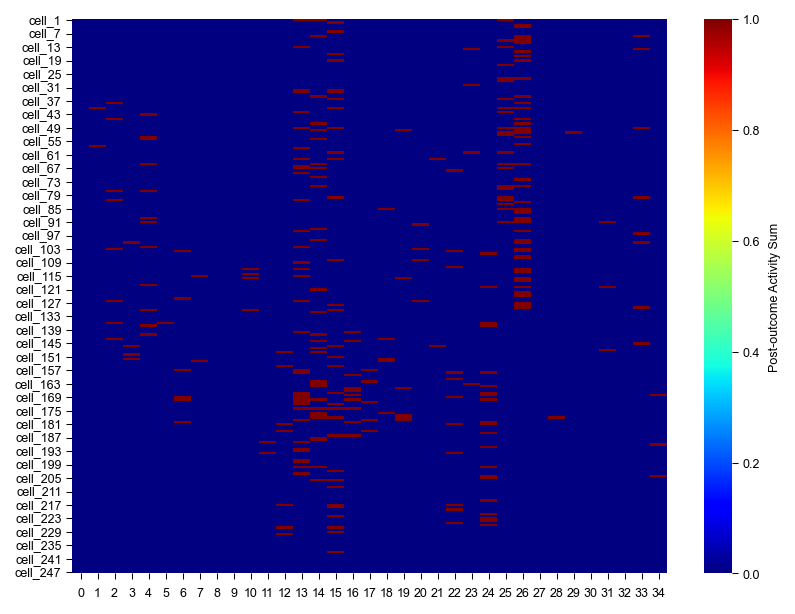

In [23]:
sns.heatmap(post_outcome_df[cell_cols].T == 0, cmap='jet', cbar_kws={'label': 'Post-outcome Activity Sum'})

#### T- add task stage + metadata to subject dfs

In [24]:
raster_df

,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_214,cell_215,labels,subject_name,geno,session,trial_num,task_stage,trial_section,truncated_post
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True


In [25]:
def plot_task_stages(stage_dict, stage_cols, fig_size = (10, 7)):
    # Define stage_cols from the stage_dict keys (excluding internal keys starting with '_')
    stage_cols = [k for k in stage_dict.keys() if not k.startswith('_')]
    # Fix variable name: use 'axes' consistently, and squeeze data to handle shape (38,1) -> (38,)
    fig, axes = plt.subplots(len(stage_cols), 1, figsize = fig_size, layout = 'constrained')
    for index, s in enumerate(stage_cols):
        # Reshape to column vector for proper heatmap display
        data =  stage_dict[s].reshape(1, -1)
        sns.heatmap(ax = axes[index], data = data, cbar = False,  cmap = 'viridis')
        axes[index].set_title(s)



In [26]:

print(raster_df.trial_section.unique())
print(raster_df.task_stage.unique())
raster_df

['pre_outcome' 'post_outcome' 'ITI' None]
['Early_IA_Correct' 'truncated_post_outcome' 'Early_IA_Error' 0 'Late_IA'
 'Early_RS_Correct' 'Early_RS_Error' 'Late_RS']


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_214,cell_215,labels,subject_name,geno,session,trial_num,task_stage,trial_section,truncated_post
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI,True


### Run activity enrichment analysis

### Circular shuffle of frame labels 

In [27]:
## given task stage, create N label permuted versions and 

# matlab code flow:
# + create matrix (n_cells x N_shuffles), where elem at (i,j) = random frame offset for cell i at shuffle j 
# + for each shuffle, apply offset to (frame labels of interest) vector, with cells having independent offsets 
# + for each cell, calculate mean activity in offset frames 
# + calculate p-value for each cell

In [28]:
def get_frames_of_interest(raster_df, trial_section= 'post_outcome', task_stage= 'Late_RS'):
    """ Returns frames of interest for specific trial section (e.g. pre, post, ITI) and specific task stage (e.g. Late RS,or IA) """
    # bool_frames_of_interest : boolean series, with index = string of frame number and true if frame is of interest    
    bool_frames_of_interest = (raster_df['trial_section'] == trial_section) & (raster_df['task_stage'] == task_stage)
    # reset index to be numeric vals only, referencing what row in raster_df the bool_frames_of_interest are in
    bool_index_of_interest = bool_frames_of_interest.reset_index(drop = True)
    #use boolean indexing to get the row indices of the true values
    indices_of_true_values = bool_index_of_interest[bool_index_of_interest.values].index.values
    return indices_of_true_values


    

In [29]:
# OPTIMIZATION 1: Numba-accelerated column rolling
from numba import jit, prange

@jit(nopython=True, parallel=True)
def random_roll_columns_numba(matrix, shifts):
    """
    Fast column rolling using Numba JIT compilation.
    
    Parameters:
    matrix: (n_frames, n_cells) array
    shifts: (n_cells,) array of shift amounts for each cell
    
    Returns:
    (n_frames, n_cells) array with each column circularly shifted
    """
    n_frames, n_cells = matrix.shape
    result = np.empty_like(matrix)
    
    # Parallel loop over cells
    for cell in prange(n_cells):
        shift = shifts[cell]
        for frame in range(n_frames):
            result[frame, cell] = matrix[(frame - shift) % n_frames, cell]
    
    return result

def random_roll_columns_fast(matrix, max_shift=None, random_seed=None):
    """
    Wrapper for numba-accelerated rolling that matches original API.
    """
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    n_rows, n_cols = matrix.shape
    if max_shift is None:
        max_shift = n_rows - 1
    
    # Generate shifts (positive-only, matching MATLAB)
    shifts = rng.integers(1, max_shift + 1, size=n_cols)
    
    # Call numba-accelerated function
    return random_roll_columns_numba(matrix, shifts)

print("Numba optimization loaded successfully")
# OPTIMIZATION shuffle: Numpy-only shuffle processing (FIXED to match OLD output structure)
def create_shuffled_df_optimized(args):
    """Optimized version matching OLD output structure."""
    df, cell_col, random_seed = args
    
    # Extract numpy arrays once
    cell_data = df[cell_col].values
    
    # Roll using fast numba version
    rolled = random_roll_columns_fast(cell_data, random_seed=random_seed)
    
    # Create rolled DataFrame
    rolled_df = pd.DataFrame(rolled, columns=cell_col, index=df.index)
    rolled_df['task_stage'] = df['task_stage']
    rolled_df['trial_section'] = df['trial_section']
    
    # Use same groupby logic as OLD
    mean_section_stage_act = rolled_df[
        rolled_df['trial_section'] == 'post_outcome'
    ].groupby(by=['task_stage', 'trial_section'])[cell_col].mean()
    
    # Add shuffle seed as a COLUMN (not row)
    mean_section_stage_act['shuffle_seed'] = random_seed
    
    return mean_section_stage_act

Numba optimization loaded successfully


In [30]:
def random_roll_columns(matrix, max_shift=None, random_seed=None):
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    n_rows, n_cols = matrix.shape
    if max_shift is None:
        max_shift = n_rows - 1  # Match MATLAB: num_cols - 1
    
    # Generate POSITIVE-ONLY shifts from 1 to max_shift (matching MATLAB's randi)
    shifts = rng.integers(1, max_shift + 1, size=n_cols)  # 1 to max_shift inclusive
    
    # Apply shifts with wrapping
    rows = np.arange(n_rows)[:, np.newaxis]
    shifted_indices = (rows - shifts) % n_rows
    return matrix[shifted_indices, np.arange(n_cols)]

def random_roll_columns_OLD(matrix, max_shift=None, random_seed=None):
    """
    Roll each column up or down by a random amount.
    Parameters:
    matrix (np.ndarray): 2D input array (rows × columns)
    max_shift (int, optional): Maximum shift amount. If None, uses row count.
    random_seed (int, optional): For reproducible results.
    
    Returns:
    np.ndarray: Matrix with each column rolled independently.
    """
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    n_rows, n_cols = matrix.shape
    if max_shift is None:
        max_shift = n_rows
    
    # Generate one random shift per column
    shifts = rng.integers(-max_shift, max_shift + 1, size=n_cols)
    # Create row indices for each column
    rows = np.arange(n_rows)[:, np.newaxis]  # Column vector of row indices    
    # Apply shifts with wrapping
    shifted_indices = (rows - shifts) % n_rows #if the shift size is > than the number of rows, it will wrap 
    # Use advanced indexing to get the rolled matrix
    return matrix[shifted_indices, np.arange(n_cols)]
 

#### test col rolling 

In [31]:

mat = np.arange(1, 10)[:, np.newaxis] + np.zeros(10, dtype=int)
print("Original matrix:")
print(mat)

rolled = random_roll_columns(mat,random_seed = None)
print("\nAfter random column rolling:")
print(rolled)

Original matrix:
[[1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2]
 [3 3 3 3 3 3 3 3 3 3]
 [4 4 4 4 4 4 4 4 4 4]
 [5 5 5 5 5 5 5 5 5 5]
 [6 6 6 6 6 6 6 6 6 6]
 [7 7 7 7 7 7 7 7 7 7]
 [8 8 8 8 8 8 8 8 8 8]
 [9 9 9 9 9 9 9 9 9 9]]

After random column rolling:
[[5 6 9 5 9 6 8 4 5 3]
 [6 7 1 6 1 7 9 5 6 4]
 [7 8 2 7 2 8 1 6 7 5]
 [8 9 3 8 3 9 2 7 8 6]
 [9 1 4 9 4 1 3 8 9 7]
 [1 2 5 1 5 2 4 9 1 8]
 [2 3 6 2 6 3 5 1 2 9]
 [3 4 7 3 7 4 6 2 3 1]
 [4 5 8 4 8 5 7 3 4 2]]


Text(0.5, 1.0, 'Rolled Data')

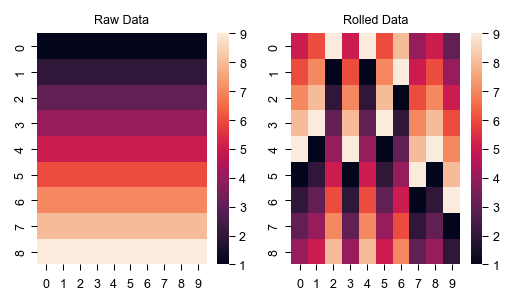

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
sns.heatmap(ax = axes[0], data = mat)
axes[0].set_title('Raw Data')

sns.heatmap(ax = axes[1], data = rolled)
axes[1].set_title('Rolled Data')


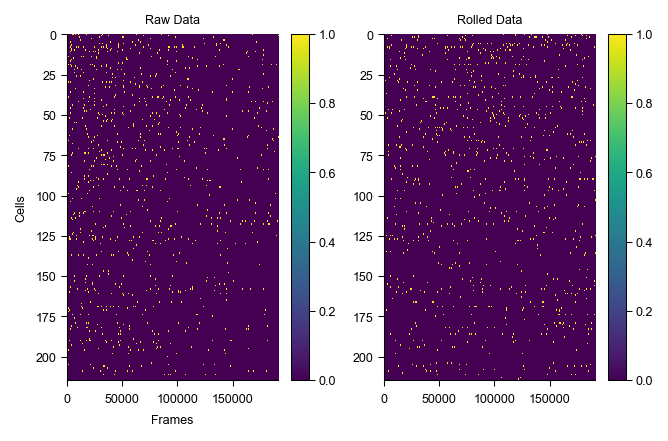

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
# Use imshow instead of seaborn heatmap for large data
im = axes[0].imshow(raster_df[cell_col].values.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title('Raw Data')
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Cells')
plt.colorbar(im, ax=axes[0])

# For the rolled data
data = raster_df.loc[:, cell_col].values
roll_data = random_roll_columns(data)
im2 = axes[1].imshow(roll_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[1].set_title('Rolled Data')
plt.colorbar(im2, ax=axes[1])


In [34]:
def get_mean_postoutcome_stage_activity(input_df, cell_col, label_col='task_stage', section_col = 'trial_section', post_outcome_label='post_outcome'):
    """ For groupby operation that returns mean activity for post-outcome stage of each cell in each section """
    mean_section_stage_act = input_df.groupby(by = [label_col, section_col])[cell_col].mean() #325 ms
    return mean_section_stage_act.loc[(slice(None),post_outcome_label),:]    

#unoptimized version for reference
def create_shuffled_df(args):
    """Helper function for parallel processing"""
    df, cell_col, random_seed = args
    roll_data = random_roll_columns(df[cell_col].values, random_seed= random_seed)
    rolled_df = pd.DataFrame(roll_data, columns=cell_col, index=df.index).join(df.drop(columns = cell_col))
    mean_section_stage_act = get_mean_postoutcome_stage_activity(rolled_df, cell_col)
    #new- 11.8.25- add shuffle seed record 
    mean_section_stage_act['shuffle_seed'] = random_seed
    return mean_section_stage_act

# 1s per shuffle is current speed

In [35]:
results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")


In [36]:
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = 10000

# Option 1: Global seed sequence across all subjects
#set shuffle storage data folder
run_output_folder = results_dir / Path(f"ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical-2  #leave 2 cores free

# Configuration
#200 minutes for 5000 shuffles/subject on 16 cores
base_seed = 42
n_subjects = len(raster_dataframes)

# Generate global seed sequence
total_shuffles = n_subjects * n_shuf_per_subject
# Generate random seeds once at the start
rng_master = np.random.default_rng(base_seed)
# Generate N random seeds (each will be different)
seed_min, seed_max = 0, 2**31

print(f"Total subjects: {n_subjects}")
print(f"Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles: {total_shuffles}")
print(f"Seed range: {seed_min} to {seed_max}")
if run_shuffles:
    # Process each subject with their allocated seed range
    all_subject_shuffles = {}

    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        
        # Get cell columns for this subject
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        
        # Allocate unique seed range for this subject
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject)
        
        print(f"  Seed range: {subject_seeds[0]} to {subject_seeds[-1]}")
        print(f"  Cells: {len(cell_col)}, Frames: {len(subject_raster_df)}")
        
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) 
            for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

        all_shuffle_means['subject_name'] = subject_name #add shuffle names to each df in output_shuff
        all_subject_shuffles[subject_name] = all_shuffle_means
        print(f"  Completed {len(output_shuff)} shuffles")
        

    print(f"\n✓ All {n_subjects} subjects processed with unique seed ranges")
    
    print(f"Saving shuffled mean activity DataFrames to {shuffle_storage_folder}")
    for subject_name, output_shuff in all_subject_shuffles.items():

        output_shuff['date_saved'] = datetime.now().strftime("%Y-%m-%d %H:%M")
        output_shuff['n_shuffles'] = n_shuf_per_subject
        #save file
        output_shuff.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   



 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_17-Nov-2025_10000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_17-Nov-2025_10000 shuffles\shuffled_dfs_10000_per_subject
16
Total subjects: 35
Shuffles per subject: 10000
Total shuffles: 350000
Seed range: 0 to 2147483648


In [37]:
#function to read parquet shuffle df files
def read_shuffle_parquet_from_folder(shuffle_storage_folder: Path) -> Dict[str, pd.DataFrame]:
    """ Reads  parquet files in folder, containing shuffled mean activity DataFrame """
                # Load all parquet files from that folder

    all_subject_shuffles = {}
    for parquet_file in shuffle_storage_folder.glob("*_shuffled_mean_activity.parquet"):
        subject_name = parquet_file.stem.replace('_shuffled_mean_activity', '')
        all_subject_shuffles[subject_name] = pd.read_parquet(parquet_file)
        print(f" Loaded: {subject_name}")
    
    print(f"Loaded {len(all_subject_shuffles)} subjects from previous run")
    return all_subject_shuffles

#### Extract parquet files and save run record

In [38]:
## save all shuffles as parquet file: 
shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

if run_shuffles:

    # After saving all shuffle parquet files, log this run
    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'shuffle_folder': str(shuffle_storage_folder),
        'n_shuffles_per_subject': n_shuf_per_subject,
        'n_subjects': len(raster_dataframes),
        'base_seed': base_seed}
    
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")
    
else: #load all subject name parquets
    # Load from most recent run
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        # Get most recent run
        latest_run = run_log_df.iloc[-1]
        shuffle_storage_folder = Path(latest_run['shuffle_folder'])
        print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles ")
        print(f"  Folder: {shuffle_storage_folder}")
        all_subject_shuffles =  read_shuffle_parquet_from_folder(shuffle_storage_folder) # Load all parquet files from that folder

    else:
        print(f"ERROR: No shuffle run log found at {shuffle_run_log_path}")
        print("Please run shuffles first (set run_shuffles=True)")
    

Loading shuffles from Timestamp: 2025-11-15 20:37:06 | 10000 Shuffles 
  Folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_15-Nov-2025_10000 shuffles\shuffled_dfs_10000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects

In [39]:
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42


#### Given shuffle array, run enrichment detection

In [40]:
## main enrichment analysis function
def get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject):
    ## code for enrichment analysis: given N shuffles, find the 95th percentile value for each cell at each task stage
    cell_threshold = all_shuffle_means.groupby('task_stage')[cell_col].agg(lambda x: np.percentile(x, 95)) #empirical?

    #get real raster mean activity data (DESPARSIFY if necessary)
    for col in cell_col:
        if isinstance(raster_df[col], pd.SparseDtype):
            raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
        raster_df.loc[:, col] = raster_df[col].astype(float)
            
    #group real data by trial_section and task_stage
    real_mean_activity = raster_df.groupby(by = ['trial_section', 'task_stage'])[cell_col].mean().loc['post_outcome', (slice(None))].drop(0)

    # FIX: Only keep stages that exist in both threshold and real data
    common_stages = cell_threshold.index.intersection(real_mean_activity.index)
    cell_threshold = cell_threshold.loc[common_stages]
    real_mean_activity = real_mean_activity.loc[common_stages]

    #get % of shuffle values greater than or equal to real cell activity
    counts_per_cell = []
    for stage, group in all_shuffle_means.groupby("task_stage"):
        # print(f"checking {stage}")
        real_values = real_mean_activity.loc[stage, cell_col] #get % of shuffle greater than or equal to real
        comparison = group[cell_col] >= real_values      # broadcast columnwise
        counts = comparison.sum()                         # count True per cell
        counts.name = stage                               # label this row
        counts_per_cell.append(counts)
    shuf_percentile = pd.DataFrame(counts_per_cell)/n_shuf_per_subject

    #get boolean mask of enriched cells
    enriched_cells = (real_mean_activity > cell_threshold)

    # melt dataframes for joining analysis
    shuf_percentile_long = shuf_percentile.reset_index().melt(id_vars = 'index', var_name = 'cell', value_name = r'percent_shuffle >= real').rename(columns = {'index': 'task_stage'})
    cell_enrich_long = enriched_cells.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'enriched') #cells activity > threshold
    cell_activity_long = real_mean_activity.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'mean') #real mean activity of cells
    cell_thresh_long = cell_threshold.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'percentile_95') #95th percentile of shuffles

    #join dataframes
    cell_ensemble_info = pd.merge(pd.merge(cell_thresh_long, cell_activity_long, on=['task_stage','cell']), cell_enrich_long, on=['task_stage','cell'])
    cell_ensemble_info = pd.merge(cell_ensemble_info, shuf_percentile_long, on=['task_stage','cell'])
    #add subject marker 
    cell_ensemble_info['subject_name'] = raster_df['subject_name'].unique()[0]
    return cell_ensemble_info


In [41]:

## ensemble info for all subjects
def get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject):
    """ Loops through all subjects and computes cell ensemble enrichment info """
    all_subject_ensemble_info = []
    for subject_name, raster_df in raster_dataframes.items():
        print(f"Processing subject: {subject_name}")
        cell_col = [c for c in raster_df.columns if 'cell' in c]
        all_shuffle_means = all_subject_shuffles[subject_name]
        subject_ensemble_info = get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject)
        all_subject_ensemble_info.append(subject_ensemble_info)
    all_ensembles = pd.concat(all_subject_ensemble_info).reset_index(drop=True)
    #add metadata
    all_ensembles['neuron_id'] = all_ensembles['subject_name'] + '-' + all_ensembles['cell'].str.replace('cell_','')
    all_ensembles['date_made'] = datetime.now().strftime("%d-%b-%Y")
    all_ensembles['n_shuffles'] = n_shuf_per_subject
    
    return all_ensembles

In [42]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)

#optional- save ensemble info as parquet
new_python_ens_file = run_output_folder / Path(f"postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
all_ensembles.to_parquet(new_python_ens_file)


Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1
Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
P

In [43]:
all_subject_shuffles

{'10_3_HET_RS1':                           cell_1    cell_2    cell_3    cell_4    cell_5  \
 task_stage                                                                 
 Early_IA_Correct        0.000000  0.212500  0.080000  0.175000  0.027500   
 Early_IA_Error          0.423333  0.120000  0.000000  0.000000  0.153333   
 Early_RS_Correct        0.000000  0.000000  0.058889  0.148889  0.000000   
 Early_RS_Error          0.000000  0.138333  0.000000  0.000000  0.038333   
 Late_IA                 0.000000  0.070000  0.016667  0.132000  0.084667   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        0.000000  0.197778  0.044444  0.046667  0.005556   
 Early_RS_Error          0.000000  0.000000  0.050000  0.050000  0.113333   
 Late_IA                 0.016667  0.032000  0.044667  0.286000  0.070000   
 Late_RS                 0.000000  0.048000  0.065333  0.009333  0.130000   
 truncated_post_outcome  0.014664  0.078300  0.052095  0.086

In [44]:
ens_matrix

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome
neuron_id,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-10,0.0,0.0,0.0,1.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-101,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-102,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
9_3_HET_RS3-95,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-96,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9_3_HET_RS3-97,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#### Within python latest shuffle run, compare within chunk stability


In [45]:
# Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
chunk_size = 1000
print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
chunked_ensemble_results = []
# Loop over each subject
for subject_name, shuffle_df in all_subject_shuffles.items():
    print(f"\n=== Processing subject: {subject_name} ===")
    
    # Get unique seeds for THIS subject
    subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
    n_seeds = len(subject_unique_seeds)
    n_chunks = n_seeds // chunk_size
    print(f"Total seeds for {subject_name}: {n_seeds}")
    print(f"Number of chunks: {n_chunks}")
    # Get corresponding raster data
    subject_raster_df = raster_dataframes[subject_name]
    cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
    
    # Loop over chunks for this subject
    for chunk_idx in range(n_chunks):
        # Get specific seeds for this chunk
        start_idx = chunk_idx * chunk_size
        end_idx = (chunk_idx + 1) * chunk_size
        chunk_seeds = subject_unique_seeds[start_idx:end_idx]
        # print(f"  Chunk {chunk_idx + 1}/{n_chunks}: seeds {chunk_seeds[0]} to {chunk_seeds[-1]} ({len(chunk_seeds)} seeds)")
        chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
        # Run enrichment analysis for this subject-chunk
        chunk_ensembles = get_cell_stage_enrichment(
            all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
        # Add metadata
        chunk_ensembles['subject_name'] = subject_name
        chunk_ensembles['chunk_index'] = chunk_idx
        chunk_ensembles['chunk_seed_min'] = chunk_seeds[0]
        chunk_ensembles['chunk_seed_max'] = chunk_seeds[-1]
        chunk_ensembles['n_seeds_in_chunk'] = len(chunk_seeds)
        chunked_ensemble_results.append(chunk_ensembles)

# Combine all subject-chunk results
all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)

print(f"\n✓ Completed all subjects and chunks")
print(f"Total results shape: {all_chunked_ensembles.shape}")
print(f"Subjects processed: {all_chunked_ensembles['subject_name'].nunique()}")
print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")

all_chunked_ensembles.head()

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1 ===
Total seeds for 10_3_HET_RS1: 10000
Number of chunks: 10

=== Processing subject: 10_3_HET_RS2 ===
Total seeds for 10_3_HET_RS2: 10000
Number of chunks: 10

=== Processing subject: 10_3_HET_RS3 ===
Total seeds for 10_3_HET_RS3: 10000
Number of chunks: 10

=== Processing subject: 13_3_HET_RS1 ===
Total seeds for 13_3_HET_RS1: 10000
Number of chunks: 10

=== Processing subject: 13_3_HET_RS2 ===
Total seeds for 13_3_HET_RS2: 10000
Number of chunks: 10

=== Processing subject: 13_3_HET_RS3 ===
Total seeds for 13_3_HET_RS3: 10000
Number of chunks: 10

=== Processing subject: 13_4_WT_RS1 ===
Total seeds for 13_4_WT_RS1: 10000
Number of chunks: 10

=== Processing subject: 13_4_WT_RS2 ===
Total seeds for 13_4_WT_RS2: 10000
Number of chunks: 10

=== Processing subject: 13_5_HET_RS1 ===
Total seeds for 13_5_HET_RS1: 10000
Number of chunks: 10

=== Processing subject: 13_5_HET_RS2 ===
Total seeds for 13_5_HET

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,chunk_index,chunk_seed_min,chunk_seed_max,n_seeds_in_chunk
0,Early_IA_Correct,cell_1,0.120000,0.001667,False,0.547,10_3_HET_RS1,0,1868,218692576,1000
1,Early_IA_Error,cell_1,0.310500,0.550000,True,0.004,10_3_HET_RS1,0,1868,218692576,1000
2,Early_RS_Correct,cell_1,0.150000,0.004444,False,0.410,10_3_HET_RS1,0,1868,218692576,1000
3,Early_RS_Error,cell_1,0.190083,0.000000,False,1.000,10_3_HET_RS1,0,1868,218692576,1000
4,Late_IA,cell_1,0.113367,0.002000,False,0.661,10_3_HET_RS1,0,1868,218692576,1000


In [46]:
all_chunked_ensembles

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,chunk_index,chunk_seed_min,chunk_seed_max,n_seeds_in_chunk
0,Early_IA_Correct,cell_1,0.120000,0.001667,False,0.547,10_3_HET_RS1,0,1868,218692576,1000
1,Early_IA_Error,cell_1,0.310500,0.550000,True,0.004,10_3_HET_RS1,0,1868,218692576,1000
2,Early_RS_Correct,cell_1,0.150000,0.004444,False,0.410,10_3_HET_RS1,0,1868,218692576,1000
3,Early_RS_Error,cell_1,0.190083,0.000000,False,1.000,10_3_HET_RS1,0,1868,218692576,1000
4,Late_IA,cell_1,0.113367,0.002000,False,0.661,10_3_HET_RS1,0,1868,218692576,1000
...,...,...,...,...,...,...,...,...,...,...,...
406395,Early_RS_Correct,cell_215,0.030000,0.000000,False,1.000,9_3_HET_RS3,9,1929446823,2146978706,1000
406396,Early_RS_Error,cell_215,0.035000,0.000000,False,1.000,9_3_HET_RS3,9,1929446823,2146978706,1000
406397,Late_IA,cell_215,0.022033,0.000000,False,1.000,9_3_HET_RS3,9,1929446823,2146978706,1000
406398,Late_RS,cell_215,0.025000,0.017500,False,0.102,9_3_HET_RS3,9,1929446823,2146978706,1000


In [47]:
enriched_by_chunk = all_chunked_ensembles.pivot_table(
    index=['subject_name', 'task_stage', 'cell'],
    columns='chunk_index',
    values='enriched',
    aggfunc='first')

enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
chunk_col = [c for c in enriched_by_chunk.columns if 'chunk_' in c]
# Add summary columns
enriched_by_chunk['n_chunks_enriched'] = enriched_by_chunk.sum(axis=1)  # Count True across chunks
enriched_by_chunk['pct_chunks_enriched'] = enriched_by_chunk['n_chunks_enriched'] / len(chunk_col) * 100

enriched_by_chunk = enriched_by_chunk.reset_index()
enriched_by_chunk.head()

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,n_chunks_enriched,pct_chunks_enriched
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False,False,False,False,False,False,0,0.0
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False,False,False,False,False,False,0,0.0
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False,False,False,False,False,False,0,0.0
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False,False,False,False,False,False,0,0.0
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False,False,False,False,False,False,0,0.0


<Axes: >

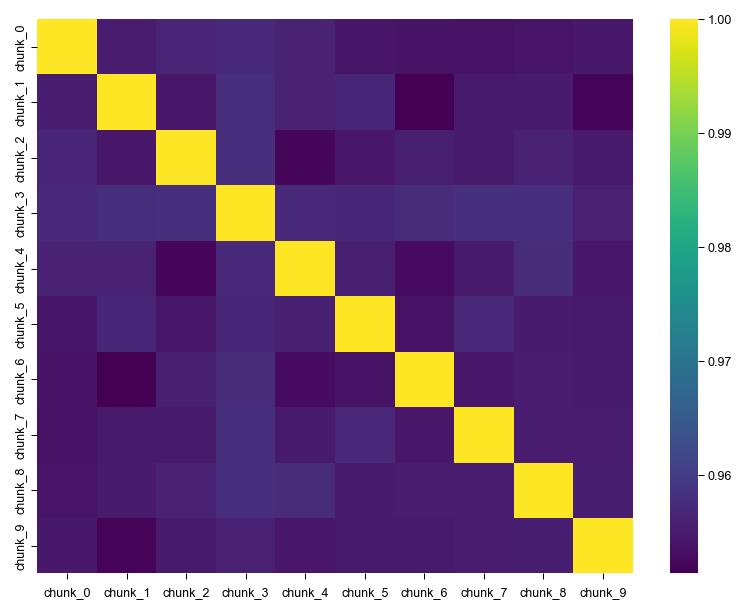

In [48]:
sns.heatmap(enriched_by_chunk[chunk_col].corr(), vmax = 1, cmap='viridis')   


#### import canon parquet, old and new Matlab TACOS


In [49]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())
canonical_data.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.0,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.0,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.0,False


In [50]:
#get ensemble info from canon df
canon_ensembles  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canon_ensembles.tail(3)

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-98,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-99,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
n_total_units = canonical_data.groupby(by = 'geno_day')['unique_ID'].nunique()
print(f"Total canon units {n_total_units.sum()}")
n_total_units
#cloudrun 4776 units 

Total canon units 4776


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64

In [52]:
#ran matlb ensemble detection 11/13/25 at 8pm
new_taco = data_dir / Path(r"WT_CLNZ_complexTACO- neurons_activity by task phase_13-Nov-2025.xls")
new_taco = pd.read_excel(new_taco,na_values = -99).replace(-99, np.nan)

#original taco from 12/10/24 with 1k shuffles
# canon_taco = data_dir / Path(r"main_datasets_complexTACO- neurons_activity by task phase_10-Dec-2024_1kShuff.xls")
# canon_taco = pd.read_excel(canon_taco,na_values = -99).replace(-99, np.nan)

#get metadata
frame_cols = [c for c in canon_taco.columns if 'f_' in c]
non_frame_cols = [c for c in canon_taco.columns if 'f_' not in c]
post_stage_names = ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA',
 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct','post_outcome_Late_RS']
print(non_frame_cols)
print(f" Unique canon cells: {canon_taco.groupby(by = 'name')['neuron_ID'].nunique().sum()}")

# #get canon/original post taco
# canon_post_taco = canon_taco[ post_stage_names +['name','geno_day','geno','neuron_ID']].copy()
# canon_post_taco.rename({old:old.replace("post_outcome_","") for old in post_stage_names},axis=1, inplace=True)
# canon_post_taco['unique_ID'] = canon_post_taco['name'].str.cat(canon_post_taco['neuron_ID'].astype(str), sep="-")

#get only post-outcome stages
new_taco_post = new_taco[post_stage_names+ ['name','geno_day','geno','neuron_ID']].copy()
new_taco_post.rename({old:old.replace("post_outcome_","") for old in post_stage_names}, axis=1, inplace=True)
new_taco_post['unique_ID'] =new_taco_post['name'].str.cat(new_taco_post['neuron_ID'].astype(str), sep="-")



['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'baseline_sig_cells', 'name', 'geno_day', 'geno', 'neuron_ID', 'Var1_1', 'Var1_2', 'Var1_3', 'Var1_4', 'Var1_5', 'Var1_6']
 Unique canon cells: 5961


In [63]:
new_taco.isnull().sum() 

pre_outcome_Early_IA_Error       1087
pre_outcome_Early_IA_Correct        0
pre_outcome_Late_IA                 0
pre_outcome_Early_RS_Error          0
pre_outcome_Early_RS_Correct        0
pre_outcome_Late_RS                 0
post_outcome_Early_IA_Error      1087
post_outcome_Early_IA_Correct       0
post_outcome_Late_IA                0
post_outcome_Early_RS_Error         0
post_outcome_Early_RS_Correct       0
post_outcome_Late_RS                0
ITI_Early_IA_Error               1087
ITI_Early_IA_Correct                0
ITI_Late_IA                         0
ITI_Early_RS_Error                  0
ITI_Early_RS_Correct                0
ITI_Late_RS                         0
baseline_sig_cells                  0
name                                0
geno_day                            0
geno                                0
neuron_ID                           0
peak_dff_threshold_percentile       0
Var1_1                              0
Var1_2                              0
Var1_3      

In [85]:
# test if it's a correlation calculation issue:
# Test one specific subject between OLD and NEW MATLAB
test_subject = '10_3_HET_RS1'

old_subject = canon_post_taco[canon_post_taco['name'] == test_subject]
new_subject = new_taco_post[new_taco_post['name'] == test_subject]

print(f"{test_subject} OLD neurons: {len(old_subject)}")
print(f"{test_subject} NEW neurons: {len(new_subject)}")

print(f"old vs new MATLAB subject correlations:")
for stage in stage_names:
    corr = old_subject.set_index('unique_ID')[stage].corr(
        new_subject.set_index('unique_ID')[stage])
    print(f"{stage}: {corr:.3f}")

print(f"old vs subchunk MATLAB subject correlations:")
for stage in stage_names:
    corr = old_subject.set_index('unique_ID')[stage].corr(
        enrich_chunk_1.set_index('neuron_ID')[stage])
    print(f"{stage}: {corr:.3f}")


print(f"new matlab vs subchunk MATLAB subject correlations:")
for stage in stage_names:
    corr = new_subject.set_index('unique_ID')[stage].corr(
        enrich_chunk_1.set_index('neuron_ID')[stage])
    print(f"{stage}: {corr:.3f}")

10_3_HET_RS1 OLD neurons: 136
10_3_HET_RS1 NEW neurons: 136
old vs new MATLAB subject correlations:
Early_IA_Error: 0.567
Early_IA_Correct: 0.508
Late_IA: 0.525
Early_RS_Error: 0.543
Early_RS_Correct: 0.543
Late_RS: 0.628
old vs subchunk MATLAB subject correlations:
Early_IA_Error: 0.567
Early_IA_Correct: 0.552
Late_IA: 0.525
Early_RS_Error: 0.517
Early_RS_Correct: 0.618
Late_RS: 0.601
new matlab vs subchunk MATLAB subject correlations:
Early_IA_Error: 1.000
Early_IA_Correct: 0.968
Late_IA: 1.000
Early_RS_Error: 0.957
Early_RS_Correct: 0.869
Late_RS: 0.957


In [81]:
new_subject

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,unique_ID
0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,10_3_HET_RS1-1
1,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,10_3_HET_RS1-2
2,1.0,0,1,1,0,0,10_3_HET_RS1,HET RS1,HET,3,10_3_HET_RS1-3
3,0.0,0,1,0,0,0,10_3_HET_RS1,HET RS1,HET,4,10_3_HET_RS1-4
4,0.0,1,0,0,1,0,10_3_HET_RS1,HET RS1,HET,5,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...
131,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,132,10_3_HET_RS1-132
132,1.0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,133,10_3_HET_RS1-133
133,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,134,10_3_HET_RS1-134
134,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,135,10_3_HET_RS1-135


In [78]:
old_subject

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,unique_ID
0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,10_3_HET_RS1-1
1,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,10_3_HET_RS1-2
2,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3,10_3_HET_RS1-3
3,0.0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4,10_3_HET_RS1-4
4,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...
131,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,132,10_3_HET_RS1-132
132,0.0,1,0,1,0,0,10_3_HET_RS1,HET RS1,HET,133,10_3_HET_RS1-133
133,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,134,10_3_HET_RS1-134
134,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,135,10_3_HET_RS1-135


In [86]:
enrich_chunk_1

,name,neuron_ID,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
136,10_3_HET_RS1,10_3_HET_RS1-1,1,0,0,0,0,0
137,10_3_HET_RS1,10_3_HET_RS1-2,0,0,0,0,0,0
138,10_3_HET_RS1,10_3_HET_RS1-3,1,0,1,1,0,0
139,10_3_HET_RS1,10_3_HET_RS1-4,0,0,1,0,0,0
140,10_3_HET_RS1,10_3_HET_RS1-5,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
267,10_3_HET_RS1,10_3_HET_RS1-132,0,0,0,0,0,0
268,10_3_HET_RS1,10_3_HET_RS1-133,1,0,0,1,0,0
269,10_3_HET_RS1,10_3_HET_RS1-134,0,0,0,0,0,0
270,10_3_HET_RS1,10_3_HET_RS1-135,0,0,0,0,0,0


Text(0.5, 1.0, 'NEW TACO')

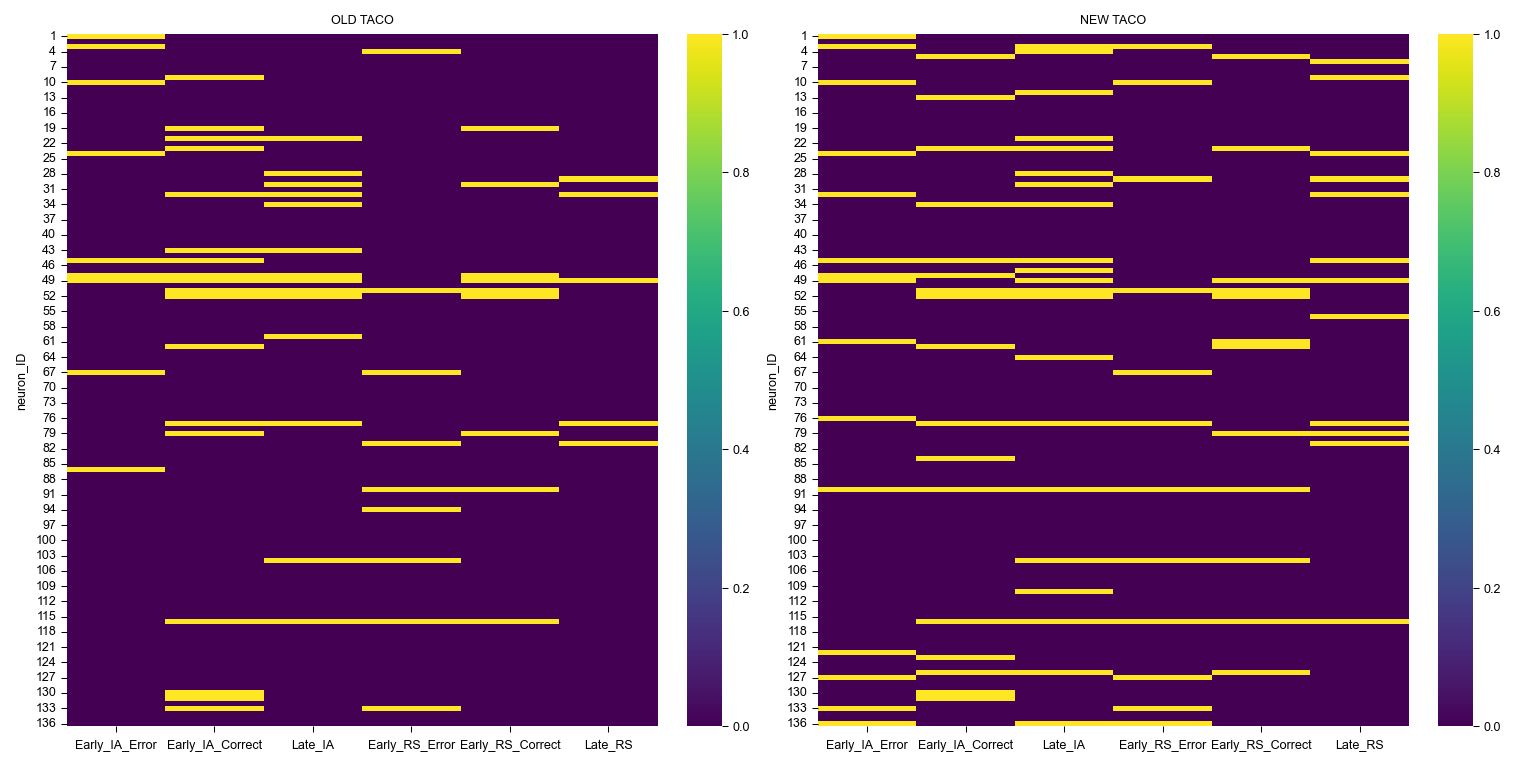

In [61]:
fig,ax = plt.subplots(1,2, figsize = (10,5), layout = 'constrained')
sns.heatmap(ax = ax[0], data = old_subject.set_index('neuron_ID')[stage_names], cmap='viridis', vmin=0, vmax=1)
ax[0].set_title('OLD TACO')
sns.heatmap(ax = ax[1], data = new_subject.set_index('neuron_ID')[stage_names], cmap='viridis', vmin=0, vmax=1)
ax[1].set_title('NEW TACO')

#### Compare MATLAB- 10 1000 shuffle draws for 1 subject

In [67]:
test_flag = "test"
test_folder = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\MATLAB Single Subject Test Data")

## read and import all xls files in test folder
all_xls_files = [x for x in test_folder.glob("*.xls") if test_flag in x.stem]
all_test_dfs = []
for xls_file in all_xls_files:
    test_n  = xls_file.stem.split('_')[1]
    df = pd.read_excel(xls_file)
    df["test_num"] = test_n
    all_test_dfs.append(df)
    print(f"Loaded: {test_n} | Shape: {df.shape}")


Loaded: 10 | Shape: (136, 67)
Loaded: 1 | Shape: (136, 67)
Loaded: 2 | Shape: (136, 67)
Loaded: 3 | Shape: (136, 67)
Loaded: 4 | Shape: (136, 67)
Loaded: 5 | Shape: (136, 67)
Loaded: 6 | Shape: (136, 67)
Loaded: 7 | Shape: (136, 67)
Loaded: 8 | Shape: (136, 67)
Loaded: 9 | Shape: (136, 67)


In [68]:
matlab_test_chunks = pd.concat(all_test_dfs).reset_index(drop=True)

matlab_stage_cols = ['post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS'] 
matlab_metacol = ['name', 'geno_day', 'neuron_ID', 'test_num']
matlab_test_df = matlab_test_chunks[matlab_metacol + matlab_stage_cols].rename(columns = {old:old.replace("post_outcome_","") for old in matlab_stage_cols})
matlab_test_df['neuron_ID'] = matlab_test_df['name'] + '-' + matlab_test_df['neuron_ID'].astype(str)
matlab_test_df.test_num = matlab_test_df.test_num.astype(int)
matlab_test_df.tail()

,name,geno_day,neuron_ID,test_num,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
1355,10_3_HET_RS1,HET RS1,10_3_HET_RS1-132,9,0,0,0,0,0,0
1356,10_3_HET_RS1,HET RS1,10_3_HET_RS1-133,9,1,0,0,1,0,0
1357,10_3_HET_RS1,HET RS1,10_3_HET_RS1-134,9,0,0,0,0,0,0
1358,10_3_HET_RS1,HET RS1,10_3_HET_RS1-135,9,0,0,0,0,0,0
1359,10_3_HET_RS1,HET RS1,10_3_HET_RS1-136,9,1,0,1,1,0,0


In [69]:
#make long format for comparison
matlab_test_long = matlab_test_df.melt(id_vars = matlab_metacol, var_name = 'task_stage', value_name = 'enriched')
matlab_test_long.tail()

,name,geno_day,neuron_ID,test_num,task_stage,enriched
8155,10_3_HET_RS1,HET RS1,10_3_HET_RS1-132,9,Late_RS,0
8156,10_3_HET_RS1,HET RS1,10_3_HET_RS1-133,9,Late_RS,0
8157,10_3_HET_RS1,HET RS1,10_3_HET_RS1-134,9,Late_RS,0
8158,10_3_HET_RS1,HET RS1,10_3_HET_RS1-135,9,Late_RS,0
8159,10_3_HET_RS1,HET RS1,10_3_HET_RS1-136,9,Late_RS,0


In [70]:
enrich_matlab_test = matlab_test_long.pivot_table(index=['name', 'task_stage', 'neuron_ID'], columns='test_num', values='enriched', aggfunc='first')

enrich_matlab_test.columns = [f'chunk_{i}' for i in enrich_matlab_test.columns]
chunk_col = [c for c in enrich_matlab_test.columns if 'chunk_' in c]
# Add summary columns
enrich_matlab_test['n_chunks_enriched'] = enrich_matlab_test.sum(axis=1)  # Count True across chunks
enrich_matlab_test['pct_chunks_enriched'] = enrich_matlab_test['n_chunks_enriched'] / len(chunk_col) * 100

enrich_matlab_test = enrich_matlab_test.reset_index()

enrich_matlab_test.head()

,name,task_stage,neuron_ID,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,chunk_10,n_chunks_enriched,pct_chunks_enriched
0,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-1,0,0,0,0,0,0,0,0,0,0,0,0.0
1,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-10,0,0,0,0,0,0,0,0,0,0,0,0.0
2,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-100,0,0,0,0,0,0,0,0,0,0,0,0.0
3,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-101,0,0,0,0,0,0,0,0,0,0,0,0.0
4,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-102,0,0,0,0,0,0,0,0,0,0,0,0.0


In [71]:
matlab_test_corr = enrich_matlab_test[chunk_col].corr()
matlab_test_corr

,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,chunk_10
chunk_1,1.000000,0.944771,0.963192,0.926566,0.945661,0.950821,0.951457,0.957740,0.951976,0.951069
chunk_2,0.944771,1.000000,0.956095,0.944092,0.939032,0.981195,0.944771,0.939032,0.945576,0.956520
chunk_3,0.963192,0.956095,1.000000,0.950121,0.945061,0.962166,0.963192,0.957375,0.939389,0.962610
chunk_4,0.926566,0.944092,0.950121,1.000000,0.933097,0.950121,0.938817,0.945292,0.939601,0.938158
chunk_5,0.945661,0.939032,0.945061,0.933097,1.000000,0.945061,0.933581,0.951907,0.946161,0.969681
chunk_6,0.950821,0.981195,0.962166,0.950121,0.945061,1.000000,0.963192,0.957375,0.951646,0.962610
chunk_7,0.951457,0.944771,0.963192,0.938817,0.933581,0.963192,1.000000,0.981899,0.939952,0.963320
chunk_8,0.957740,0.939032,0.957375,0.945292,0.951907,0.957375,0.981899,1.000000,0.958129,0.957486
chunk_9,0.951976,0.945576,0.939389,0.939601,0.946161,0.951646,0.939952,0.958129,1.000000,0.939601
chunk_10,0.951069,0.956520,0.962610,0.938158,0.969681,0.962610,0.963320,0.957486,0.939601,1.000000


Text(0.5, 1.0, ' Comparing 10 blocks of 1000 shuffles each | MATLAB Testing on 1 subject')

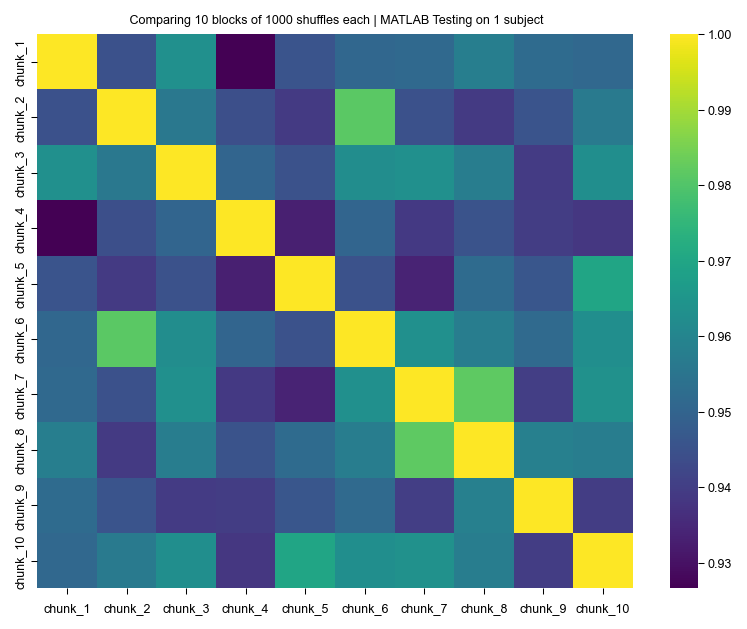

In [72]:
sns.heatmap(enrich_matlab_test[chunk_col].corr(), vmax = 1, cmap='viridis')   
plt.title(f" Comparing 10 blocks of 1000 shuffles each | MATLAB Testing on 1 subject")

In [73]:
## compare matlab chunk 1 to python chunk 0 for same subject
enrich_chunk_1 = matlab_test_df.loc[matlab_test_df.test_num ==1, ['name','neuron_ID']+stage_names].copy()
print(enrich_chunk_1.shape)
#combine OG taco with new ensembles
new_suffix = '_new_python'
single_subj_chunk = enrich_chunk_1.set_index('neuron_ID').join(ens_matrix.astype(float), how = 'inner', rsuffix = new_suffix)
df = single_subj_chunk
print(df.shape)

# Compute correlation for each stage
correlations = {stage: df[stage].corr(df[stage +new_suffix]) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of a new 1000 single subj. shuff batch MATLAB vs new Python: \n{corr_df}")

(136, 8)
(136, 14)
 Correlation of a new 1000 single subj. shuff batch MATLAB vs new Python: 
                  Correlation
Early_IA_Error       0.925069
Early_IA_Correct     0.969195
Late_IA              0.943685
Early_RS_Error       0.914947
Early_RS_Correct     0.868719
Late_RS              1.000000


In [93]:
canon_ensembles.reset_index(level = [1,2])

,geno,geno_day,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,,,,,,,,
10_3_HET_RS1-1,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-101,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-104,HET,Het VEH,0.0,0.0,1.0,1.0,0.0,0.0
10_3_HET_RS1-107,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
9_3_HET_RS3-95,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-96,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0


In [95]:
#compare to ensembles in parquet: canon_ensembles

single_subj_chunk = enrich_chunk_1.set_index('neuron_ID').join(canon_ensembles.reset_index(level = [1,2]), how = 'inner', rsuffix = new_suffix)
df = single_subj_chunk
print(df.shape)

# Compute correlation for each stage
correlations = {stage: df[stage].corr(df[stage +new_suffix]) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of a new 1000 single subj. shuff batch MATLAB vs canon parquet: \n{corr_df}")

(97, 15)
 Correlation of a new 1000 single subj. shuff batch MATLAB vs canon parquet: 
                  Correlation
Early_IA_Error       0.551168
Early_IA_Correct     0.522504
Late_IA              0.536470
Early_RS_Error       0.500010
Early_RS_Correct     0.604314
Late_RS              0.592596


In [74]:
enrich_chunk_1

,name,neuron_ID,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
136,10_3_HET_RS1,10_3_HET_RS1-1,1,0,0,0,0,0
137,10_3_HET_RS1,10_3_HET_RS1-2,0,0,0,0,0,0
138,10_3_HET_RS1,10_3_HET_RS1-3,1,0,1,1,0,0
139,10_3_HET_RS1,10_3_HET_RS1-4,0,0,1,0,0,0
140,10_3_HET_RS1,10_3_HET_RS1-5,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
267,10_3_HET_RS1,10_3_HET_RS1-132,0,0,0,0,0,0
268,10_3_HET_RS1,10_3_HET_RS1-133,1,0,0,1,0,0
269,10_3_HET_RS1,10_3_HET_RS1-134,0,0,0,0,0,0
270,10_3_HET_RS1,10_3_HET_RS1-135,0,0,0,0,0,0


In [ ]:
canon_post_taco.set_index('unique_ID')

In [ ]:
#combine OG taco with new ensembles
new_suffix = '_old_matlab'
single_subj_chunk = enrich_chunk_1.set_index('neuron_ID').join(canon_post_taco.set_index('unique_ID'), how = 'inner', rsuffix = new_suffix)
df = single_subj_chunk
print(df.shape)

# Compute correlation for each stage
correlations = {stage: df[stage].corr(df[stage +new_suffix]) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of a new 1000 single subj. shuff batch MATLAB vs old TACO: \n{corr_df}")

In [ ]:
df

#### Compare MATLAB OLD TACO enrichment vectors with NEWEST PYTHON enrichment vector

In [ ]:
#combine OG taco with new ensembles
combined_ens = canon_post_taco.set_index('unique_ID').join(ens_matrix.astype(float), how = 'inner', rsuffix = '_new')

df = combined_ens
# Compute correlation for each stage
correlations = {stage: df[stage].corr(df[stage + '_new']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of OLD MATLAB vs new Python implementation of method: \n{corr_df}")

In [ ]:
#question, how do you deal with NaN values? THey should be the same as 0 values in this case, 
#get jaqquard index between canonical taco and new python ensembles
from sklearn.metrics import jaccard_score
jaqquard_scores = {}
for stage in stage_names:
    #get boolean arrays for each stage
    canon_array = combined_ens[stage].fillna(0).astype(bool).values
    new_array = combined_ens[stage + '_new'].fillna(0).astype(bool).values
    score = jaccard_score(canon_array, new_array)
    jaqquard_scores[stage] = score
    print(f" Jaqquard score for {stage}: {score:.4f}")

#### Compare old python versus new python

In [ ]:
old_shuffle_storage_folder = Path(
    r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_14-Nov-2025_1000 shuffles\shuffled_dfs_1000_per_subject")
print(f"  Folder: {old_shuffle_storage_folder}")

old_python_shuffles =   read_shuffle_parquet_from_folder(old_shuffle_storage_folder) # Load all parquet files from that folder
old_python_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, old_python_shuffles, n_shuf_per_subject)
old_python_ens_matrix =old_python_ensembles .pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)


In [ ]:
raster_dataframes

In [ ]:
old_python_shuffles

In [ ]:
old_python_ens_matrix.index.name = 'unique_ID'
old_python_ens_matrix

In [ ]:
#compare latest MATLAB TACO with old matlab TACO (used in papwer)
python_old_new = old_python_ens_matrix.loc[:,stage_names].join(
    ens_matrix.astype(float), how = 'inner', rsuffix = '_new')
python_old_new

In [ ]:
print(f"Newest Python RUN algorithm: ensemble % enriched across all cells: \n{ens_matrix[stage_names].mean()}")

In [ ]:
print(f"Old Python RUN algorithm: ensemble % enriched across all cells: \n{old_python_ens_matrix[stage_names].mean()}")

In [ ]:
##compare old vs new taco ensembles
df = python_old_new
correlations = {stage: df[stage].corr(df[stage + '_new']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for OLD Python vs NEW Python (same code): \n{corr_df}")

#### Compare MATLAB OLD vs MATLAB NEW enrichment vectors

In [ ]:
#compare latest MATLAB TACO with old matlab TACO (used in papwer)
taco_old_new = new_taco_post.set_index('unique_ID').loc[:,stage_names].join(canon_post_taco.set_index('unique_ID'), how = 'inner', rsuffix = '_new')
taco_old_new

In [ ]:
n_total_units = taco_old_new.reset_index().groupby(by = 'geno_day')['unique_ID'].nunique()
print(f"Total canon units {n_total_units.sum()}")
n_total_units

In [ ]:
print(f"Newest MATLAB RUN algorithm: ensemble % enriched across all cells: \n{new_taco_post[stage_names].mean()}")

In [ ]:
print(f"Old MATLAB base TACO algorithm: ensemble % enriched across all cells: \n{canon_post_taco[stage_names].mean()}")

In [ ]:
##compare old vs new taco ensembles
df = taco_old_new
correlations = {stage: df[stage].corr(df[stage + '_new']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for OLD taco vs NEW run of TACO (same code): \n{corr_df}")

#### Debug the lost cell issue:

In [ ]:
#find where cells dropped
import custom_module_imports as cmi
import pandas as pd

# Load the raw files first
enriched_by_stage_path = data_location / f'main_datasets_complexTACO- neurons_activity by task phase_10-Dec-2024.xls'
post_activity_timeseries = data_location / f'post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv'

# Check source files
cell_period_active = pd.read_excel(enriched_by_stage_path)
outcome_post = pd.read_csv(post_activity_timeseries, header=0, low_memory=False)

print(f"1. Enrichment file unique neurons: {cell_period_active['neuron_ID'].nunique()}")
print(f"2. Timeseries file unique neurons: {outcome_post['neuron_ID'].nunique()}")

# After dropna
cols_to_drop = ['threshold_with_shuffle','peak_dff_threshold_percentile','drop_low_value_peak_events','cutoff_filter','peak_event_cutoff_percentile']
outcome_post_clean = outcome_post.drop([x for x in cols_to_drop if x in outcome_post], axis=1).dropna(subset=['task_phase_vec'])
print(f"3. After dropna(task_phase_vec): {outcome_post_clean['neuron_ID'].nunique()} unique neurons")

# Get unique_ID counts
cmi.hf.annotate_csv(outcome_post_clean, 'name')
outcome_post_clean['unique_ID_temp'] = outcome_post_clean['name'].str.cat(outcome_post_clean['neuron_ID'].astype(str), sep='-')
print(f"4. Unique cells (name + neuron_ID): {outcome_post_clean['unique_ID_temp'].nunique()}")

# Now run the full function
trial_tseries_df_norm = cmi.pp.get_normed_trial_tseries(enriched_by_stage_path, post_activity_timeseries, hyper_param_dict)
print(f"5. After full preprocessing: {trial_tseries_df_norm['unique_ID'].nunique()} unique cells")

#### compare new/old cell count

In [ ]:
print(canonical_data.groupby(by = 'geno_day')['unique_ID'].nunique())
print(f" Canon unique cells: {canonical_data['unique_ID'].nunique()}")

In [ ]:
subject_cell_count_old = canonical_data.groupby(by = 'name')['unique_ID'].nunique()
subject_cell_count_old

In [ ]:
subject_cell_count_new = all_ensembles.groupby(by = 'subject_name')['neuron_id'].nunique()
subject_cell_count_new

In [ ]:
all_ensembles
print(f" new unique cells: {all_ensembles['neuron_id'].nunique()}")

In [ ]:
subj_cell_comp = subject_cell_count_old.to_frame().rename({'unique_ID': 'old_n'},axis = 1).join(
    subject_cell_count_new.to_frame().rename({'neuron_id': 'new_n'},axis = 1), lsuffix = '_old', rsuffix = '_new')

subj_cell_comp

In [ ]:
2

# Diagnostics: Python vs MATLAB Permutation Testing Comparison

This section contains diagnostic code to identify why Python and MATLAB show ~0.3 correlation in enrichment calls despite identical data and 1000 shuffles.

In [ ]:
# DIAGNOSTIC 1: Verify which random_roll_columns version is being used
print("="*60)
print("DIAGNOSTIC 1: Testing random_roll_columns version")
print("="*60)

# Test with known seed
test_matrix = np.random.rand(100, 5)  # 100 frames, 5 cells
test_seed = 42

rolled = random_roll_columns(test_matrix, random_seed=test_seed)

# Check what shifts were generated by inspecting the function
rng_test = np.random.default_rng(test_seed)
n_rows, n_cols = test_matrix.shape
max_shift = n_rows - 1
test_shifts = rng_test.integers(1, max_shift + 1, size=n_cols)

print(f"Matrix shape: {test_matrix.shape}")
print(f"Generated shifts: {test_shifts}")
print(f"Shift range: [{test_shifts.min()}, {test_shifts.max()}]")
print(f"Expected range: [1, {max_shift}]")

if test_shifts.min() >= 1 and test_shifts.max() <= max_shift:
    print("✓ NEW version (positive-only shifts) is being used")
else:
    print("✗ OLD version (negative shifts) may still be in use\!")

In [ ]:
subject_shuffles

In [ ]:
# DIAGNOSTIC 2: Compare shuffle distribution statistics
print("" + "="*60)
print("DIAGNOSTIC 2: Shuffle Distribution Statistics")
print("="*60)

# Pick one subject and stage
test_subject = "10_3_HET_RS1"
test_stage = "Early_IA_Correct"

# Get Python shuffle means
subject_shuffles = all_subject_shuffles[test_subject].reset_index()
stage_shuffles = subject_shuffles[subject_shuffles["task_stage"] == test_stage]

# Get cell columns
cell_cols = [c for c in stage_shuffles.columns if c.startswith("cell_")]
print(f" Subject: {test_subject}")
print(f"Stage: {test_stage}")
print(f"Number of cells: {len(cell_cols)}")
print(f"Number of shuffles: {len(stage_shuffles)}")

# Statistics for first 3 cells
print(f"Shuffle distribution statistics (first 3 cells):")
for cell in cell_cols[:3]:
    values = stage_shuffles[cell].values
    print(f"{cell}:")
    print(f"  Mean: {values.mean():.6f}")
    print(f"  Std:  {values.std():.6f}")
    print(f"  Min:  {values.min():.6f}")
    print(f"  Max:  {values.max():.6f}")
    print(f"  95th percentile: {np.percentile(values, 95):.6f}")
    
# Get real activity for comparison
real_df = raster_dataframes[test_subject]
real_activity = real_df[
    (real_df["trial_section"] == "post_outcome") & 
    (real_df["task_stage"] == test_stage)
][cell_cols[:3]].mean()

print(f"Real activity (first 3 cells):")
for cell in cell_cols[:3]:
    print(f"  {cell}: {real_activity[cell]:.6f}")

In [ ]:
# DIAGNOSTIC 3: Compare real activity between MATLAB and Python
print("" + "="*60)
print("DIAGNOSTIC 3: Real Activity Comparison")
print("="*60)

# Get MATLAB data for test subject
matlab_subject = canon_post_taco[canon_post_taco["name"] == test_subject].copy()
print(f"MATLAB neurons for {test_subject}: {len(matlab_subject)}")

# Get Python real activity
python_real = real_df[
    real_df["trial_section"] == "post_outcome"
].groupby("task_stage")[[c for c in real_df.columns if "cell" in c]].mean()

print(f"Python neurons for {test_subject}: {python_real.shape[1]}")

# Compare for Early_IA_Correct
if test_stage in python_real.index:
    python_stage_activity = python_real.loc[test_stage]
    
    # Match neurons - need to map cell index to neuron_ID
    # Assuming cell_1 = neuron_ID 1, cell_2 = neuron_ID 2, etc.
    print(f"First 5 cells comparison for {test_stage}:")
    print(f"{"Cell":<10} {"Python Real":<15} {"MATLAB Binary":<15}")
    print("-" * 40)
    
    for i in range(min(5, len(matlab_subject))):
        cell_name = f"cell_{i+1}"
        neuron_id = i + 1
        
        if cell_name in python_stage_activity.index:
            python_val = python_stage_activity[cell_name]
            matlab_row = matlab_subject[matlab_subject["neuron_ID"] == neuron_id]
            
            if len(matlab_row) > 0 and test_stage in matlab_row.columns:
                matlab_binary = matlab_row[test_stage].values[0]
                print(f"{cell_name:<10} {python_val:<15.6f} {matlab_binary:<15.0f}")

In [ ]:
# DIAGNOSTIC 4: Check enrichment boundary cases
print("" + "="*60)
print("DIAGNOSTIC 4: Boundary Case Analysis")
print("="*60)

# For all neurons, check disagreements
disagreements = combined_ens[combined_ens[test_stage] \!= combined_ens[f"{test_stage}_new"]].copy()

print(f"Total neurons: {len(combined_ens)}")
print(f"Disagreements for {test_stage}: {len(disagreements)} ({100*len(disagreements)/len(combined_ens):.1f}%)")

if len(disagreements) > 0:
    print(f"Breakdown of disagreements:")
    print(f"  MATLAB=1, Python=0: {len(disagreements[disagreements[test_stage] == 1])}")
    print(f"  MATLAB=0, Python=1: {len(disagreements[disagreements[test_stage] == 0])}")
    
    # This would require having the threshold values, which we would need to add to the output
    print(f" Note: To analyze how close disagreements are to thresholds,")
    print(f"      we need to save threshold values in get_cell_stage_enrichment")

In [ ]:
# DIAGNOSTIC 5: Test MATLAB vs Python shuffle approach with toy data
print(" " + "="*60)
print("DIAGNOSTIC 5: Shuffle Approach Comparison")
print("="*60)

# Create simple toy example
toy_n_frames = 50
toy_n_cells = 3
toy_raster = np.random.rand(toy_n_frames, toy_n_cells)

# Create labels: first 20 frames are "stage_A", rest are "other"
toy_labels = np.array(["other"] * toy_n_frames)
toy_labels[:20] = "stage_A"

print(f"Toy data: {toy_n_frames} frames, {toy_n_cells} cells")
print(f"Stage_A frames: 0-19 (20 frames)")

# Python approach: shuffle data, filter by original labels
python_shuffle_means = []
for seed in range(100):
    rolled = random_roll_columns(toy_raster, random_seed=seed)
    # Filter by original labels
    stage_a_activity = rolled[toy_labels == "stage_A"].mean(axis=0)
    python_shuffle_means.append(stage_a_activity)

python_shuffle_means = np.array(python_shuffle_means)  # (100, 3)
python_thresholds = np.percentile(python_shuffle_means, 95, axis=0)

# MATLAB approach: shuffle frame indices, extract at those positions
matlab_shuffle_means = []
frames_of_interest = np.where(toy_labels == "stage_A")[0]

for seed in range(100):
    rng = np.random.default_rng(seed)
    # Generate shifts for each cell
    shifts = rng.integers(1, toy_n_frames, size=toy_n_cells)
    
    # Shift frame indices for each cell
    cell_means = []
    for cell_idx in range(toy_n_cells):
        shifted_frames = (frames_of_interest + shifts[cell_idx]) % toy_n_frames
        cell_mean = toy_raster[shifted_frames, cell_idx].mean()
        cell_means.append(cell_mean)
    
    matlab_shuffle_means.append(cell_means)

matlab_shuffle_means = np.array(matlab_shuffle_means)  # (100, 3)
matlab_thresholds = np.percentile(matlab_shuffle_means, 95, axis=0)

# Compare
print(f"95th Percentile Thresholds:")
print(f"{"Method":<15} {"Cell 1":<12} {"Cell 2":<12} {"Cell 3":<12}")
print("-" * 51)
print(f"{"Python":<15} {python_thresholds[0]:<12.6f} {python_thresholds[1]:<12.6f} {python_thresholds[2]:<12.6f}")
print(f"{"MATLAB":<15} {matlab_thresholds[0]:<12.6f} {matlab_thresholds[1]:<12.6f} {matlab_thresholds[2]:<12.6f}")
print(f"{"Difference":<15} {python_thresholds[0]-matlab_thresholds[0]:<12.6f} {python_thresholds[1]-matlab_thresholds[1]:<12.6f} {python_thresholds[2]-matlab_thresholds[2]:<12.6f}")

print(f"Correlation of thresholds: {np.corrcoef(python_thresholds, matlab_thresholds)[0,1]:.4f}")

# Compare means and stds
print(f"Shuffle distribution comparison:")
for cell_idx in range(toy_n_cells):
    print(f"Cell {cell_idx+1}:")
    print(f"  Python: mean={python_shuffle_means[:, cell_idx].mean():.6f}, std={python_shuffle_means[:, cell_idx].std():.6f}")
    print(f"  MATLAB: mean={matlab_shuffle_means[:, cell_idx].mean():.6f}, std={matlab_shuffle_means[:, cell_idx].std():.6f}")

In [ ]:
# DIAGNOSTIC 5 (FIXED v2): Test MATLAB vs Python shuffle approach with toy data
print("
" + "="*60)
print("DIAGNOSTIC 5: Shuffle Approach Comparison (FIXED v2)")
print("="*60)

# Create simple toy example
toy_n_frames = 50
toy_n_cells = 3
np.random.seed(999)  # For reproducible toy data
toy_raster = np.random.rand(toy_n_frames, toy_n_cells)

# Create labels: first 20 frames are "stage_A", rest are "other"
toy_labels = np.array(["other" for _ in range(toy_n_frames)], dtype=object)
toy_labels[:20] = "stage_A"
frames_of_interest = np.arange(20)  # Explicitly: frames 0-19

print(f"Toy data: {toy_n_frames} frames, {toy_n_cells} cells")
print(f"Stage_A frames: 0-19 ({len(frames_of_interest)} frames)")
print(f"Labels check: {toy_labels[:5]} ... {toy_labels[18:22]}")

# Python approach: shuffle data, filter by original frame indices
python_shuffle_means = []
for seed in range(100):
    rolled = random_roll_columns(toy_raster, random_seed=seed)
    # Extract activity at stage_A frame positions
    stage_a_activity = rolled[frames_of_interest, :].mean(axis=0)
    python_shuffle_means.append(stage_a_activity)

python_shuffle_means = np.array(python_shuffle_means)  # (100, 3)
python_thresholds = np.percentile(python_shuffle_means, 95, axis=0)

# MATLAB approach: shuffle frame indices, extract at those positions
matlab_shuffle_means = []

for seed in range(100):
    rng = np.random.default_rng(seed)
    # Generate shifts for each cell (1 to n_frames-1)
    shifts = rng.integers(1, toy_n_frames, size=toy_n_cells)
    
    # Shift frame indices for each cell
    cell_means = []
    for cell_idx in range(toy_n_cells):
        shifted_frames = (frames_of_interest + shifts[cell_idx]) % toy_n_frames
        cell_mean = toy_raster[shifted_frames, cell_idx].mean()
        cell_means.append(cell_mean)
    
    matlab_shuffle_means.append(cell_means)

matlab_shuffle_means = np.array(matlab_shuffle_means)  # (100, 3)
matlab_thresholds = np.percentile(matlab_shuffle_means, 95, axis=0)

# Compare
print(f"
95th Percentile Thresholds:")
print(f"{"Method":<15} {"Cell 1":<12} {"Cell 2":<12} {"Cell 3":<12}")
print("-" * 51)
print(f"{"Python":<15} {python_thresholds[0]:<12.6f} {python_thresholds[1]:<12.6f} {python_thresholds[2]:<12.6f}")
print(f"{"MATLAB":<15} {matlab_thresholds[0]:<12.6f} {matlab_thresholds[1]:<12.6f} {matlab_thresholds[2]:<12.6f}")
print(f"{"Difference":<15} {python_thresholds[0]-matlab_thresholds[0]:<12.6f} {python_thresholds[1]-matlab_thresholds[1]:<12.6f} {python_thresholds[2]-matlab_thresholds[2]:<12.6f}")
print(f"{"% Diff":<15} {100*(python_thresholds[0]-matlab_thresholds[0])/matlab_thresholds[0]:<12.2f} {100*(python_thresholds[1]-matlab_thresholds[1])/matlab_thresholds[1]:<12.2f} {100*(python_thresholds[2]-matlab_thresholds[2])/matlab_thresholds[2]:<12.2f}")

print(f"
Correlation of thresholds: {np.corrcoef(python_thresholds, matlab_thresholds)[0,1]:.4f}")

# Compare means and stds
print(f"
Shuffle distribution comparison:")
for cell_idx in range(toy_n_cells):
    print(f"
Cell {cell_idx+1}:")
    print(f"  Python: mean={python_shuffle_means[:, cell_idx].mean():.6f}, std={python_shuffle_means[:, cell_idx].std():.6f}")
    print(f"  MATLAB: mean={matlab_shuffle_means[:, cell_idx].mean():.6f}, std={matlab_shuffle_means[:, cell_idx].std():.6f}")
    print(f"  Diff:   mean={python_shuffle_means[:, cell_idx].mean() - matlab_shuffle_means[:, cell_idx].mean():.6f}")

## Split-Half Reliability Test

Test: What correlation do we expect when running the SAME permutation method twice with different random seeds?

In [ ]:
# Split-half reliability test: Run Python method twice with different seed sets
print("="*60)
print("SPLIT-HALF RELIABILITY TEST")
print("="*60)
print("Testing: Same algorithm, different RNG seeds")
print()

test_subject = "10_3_HET_RS1"
test_raster_df = raster_dataframes[test_subject]
cell_cols = [c for c in test_raster_df.columns if c.startswith("cell_")]

# Run 1: Seeds 1000-1999 (simulating "Run A")
print("Running shuffle set A (seeds 1000-1999)...")
shuffle_means_A = []
for seed in range(1000, 2000):
    rolled = random_roll_columns(test_raster_df[cell_cols].values, random_seed=seed)
    rolled_df = pd.DataFrame(rolled, columns=cell_cols, index=test_raster_df.index).join(
        test_raster_df.drop(columns=cell_cols)
    )
    mean_act = rolled_df[
        rolled_df["trial_section"] == "post_outcome"
    ].groupby("task_stage")[cell_cols].mean()
    shuffle_means_A.append(mean_act)

all_shuffles_A = pd.concat(shuffle_means_A, axis=0, keys=range(1000))

# Run 2: Seeds 2000-2999 (simulating "Run B")
print("Running shuffle set B (seeds 2000-2999)...")
shuffle_means_B = []
for seed in range(2000, 3000):
    rolled = random_roll_columns(test_raster_df[cell_cols].values, random_seed=seed)
    rolled_df = pd.DataFrame(rolled, columns=cell_cols, index=test_raster_df.index).join(
        test_raster_df.drop(columns=cell_cols)
    )
    mean_act = rolled_df[
        rolled_df["trial_section"] == "post_outcome"
    ].groupby("task_stage")[cell_cols].mean()
    shuffle_means_B.append(mean_act)

all_shuffles_B = pd.concat(shuffle_means_B, axis=0, keys=range(1000))

# Calculate 95th percentile thresholds for each run
print()
print("Calculating enrichment calls...")
thresholds_A = all_shuffles_A.groupby("task_stage")[cell_cols].agg(lambda x: np.percentile(x, 95))
thresholds_B = all_shuffles_B.groupby("task_stage")[cell_cols].agg(lambda x: np.percentile(x, 95))

# Get real activity
real_activity = test_raster_df[
    test_raster_df["trial_section"] == "post_outcome"
].groupby("task_stage")[cell_cols].mean()

# Determine enrichment for each run
enriched_A = (real_activity > thresholds_A).astype(int)
enriched_B = (real_activity > thresholds_B).astype(int)

print()
print("="*60)
print("RESULTS: Correlation between Run A and Run B")
print("="*60)

stages = ["Early_IA_Error", "Early_IA_Correct", "Late_IA", 
          "Early_RS_Error", "Early_RS_Correct", "Late_RS"]

print(f"{"Stage":<20} {"Correlation":<15} {"Agreement %":<15} {"Enriched A":<12} {"Enriched B":<12}")
print("-" * 75)

correlations = {}
for stage in stages:
    if stage in enriched_A.index:
        corr = enriched_A.loc[stage].corr(enriched_B.loc[stage])
        agreement = (enriched_A.loc[stage] == enriched_B.loc[stage]).mean()
        rate_A = enriched_A.loc[stage].mean()
        rate_B = enriched_B.loc[stage].mean()
        
        correlations[stage] = corr
        print(f"{stage:<20} {corr:<15.3f} {agreement:<15.1%} {rate_A:<12.1%} {rate_B:<12.1%}")

print()
print(f"Mean correlation across stages: {np.mean(list(correlations.values())):.3f}")
print()
print("INTERPRETATION:")
print("This correlation represents the EXPECTED agreement when using")
print("the same method twice with different random seeds.")
print("Your Python vs MATLAB correlation should be compared to this baseline.")

## Data Integrity Check

Since split-half correlation is 0.94 but Python-MATLAB is 0.31, the issue must be in the INPUT DATA, not the shuffle algorithm.

In [ ]:
# Data integrity check: Compare input data between Python and MATLAB
print("="*60)
print("DATA INTEGRITY CHECK")
print("="*60)
print("Comparing: Python input data vs MATLAB assumptions")
print()

test_subject = "10_3_HET_RS1"
test_stage = "Early_IA_Correct"

# Python data
python_df = raster_dataframes[test_subject]
python_post = python_df[python_df["trial_section"] == "post_outcome"]
python_stage = python_post[python_post["task_stage"] == test_stage]

print(f"Subject: {test_subject}")
print(f"Stage: {test_stage}")
print()

print("PYTHON DATA:")
print(f"  Total frames in dataset: {len(python_df)}")
print(f"  Post-outcome frames: {len(python_post)}")
print(f"  {test_stage} post-outcome frames: {len(python_stage)}")
print(f"  Number of neurons: {len([c for c in python_df.columns if "cell" in c])}")
print()

# Check task stage distribution
print("Task stage distribution (post-outcome only):")
print(python_post["task_stage"].value_counts().sort_index())
print()

# Check if MATLAB data has same structure
matlab_neurons = canon_post_taco[canon_post_taco["name"] == test_subject]
print(f"MATLAB DATA:")
print(f"  Number of neurons: {len(matlab_neurons)}")
print(f"  Columns: {list(matlab_neurons.columns)}")
print()

# Key question: Are we analyzing the same frames?
cell_cols = [c for c in python_df.columns if "cell" in c]
python_real_means = python_post.groupby("task_stage")[cell_cols].mean()

print("="*60)
print("CRITICAL CHECK: Real activity statistics")
print("="*60)
print("If these differ, Python and MATLAB are analyzing different data\!")
print()

for stage in ["Early_IA_Correct", "Early_IA_Error", "Late_RS"]:
    if stage in python_real_means.index:
        stage_mean = python_real_means.loc[stage]
        print(f"{stage}:")
        print(f"  Mean activity across all cells: {stage_mean.mean():.6f}")
        print(f"  Std across cells: {stage_mean.std():.6f}")
        print(f"  Non-zero cells: {(stage_mean > 0).sum()} / {len(stage_mean)}")
        print(f"  Median: {stage_mean.median():.6f}")
        print()

print("="*60)
print("ACTION ITEMS")
print("="*60)
print("1. Check if MATLAB uses the same frame counts per stage")
print("2. Verify MATLAB also filters for post_outcome only")
print("3. Check if trial exclusion criteria differ")
print("4. Verify task stage definitions match")

## Performance Optimizations

Optimized shuffle functions for frequent reanalysis and high shuffle counts.

In [ ]:
# BENCHMARK: Compare old vs new performance
import time

test_subject = list(raster_dataframes.keys())[0]
test_df = raster_dataframes[test_subject]
test_cell_col = [c for c in test_df.columns if "cell" in c]
n_test_shuff = 500
print(f"Benchmarking on: {test_subject}")
print(f"Data shape: {test_df[test_cell_col].shape}")
print(f"Testing {n_test_shuff} shuffles...")

# Test OLD version
start = time.time()
output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df)((subject_raster_df, cell_col, int(seed))) 
            for seed in range(n_test_shuff))


old_time = time.time() - start
print(f"OLD version: {old_time:.2f} seconds")

# Test NEW version
start = time.time()
output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
    delayed(create_shuffled_df_optimized)((test_df, test_cell_col, int(seed))) for seed in range(n_test_shuff))
new_time = time.time() - start
print(f"NEW version: {new_time:.2f} seconds")

speedup = old_time / new_time
print(f"Speedup: {speedup:.1f}x faster")
print(f"For 1000 shuffles per subject:")
print(f"  OLD: ~{old_time * 10:.1f} seconds ({old_time * 10 / 60:.1f} minutes)")
print(f"  NEW: ~{new_time * 10:.1f} seconds ({new_time * 10 / 60:.1f} minutes)")
print(f"For all {len(raster_dataframes)} subjects with 1000 shuffles:")
print(f"  OLD: ~{old_time * 10 * len(raster_dataframes) / 60:.1f} minutes")
print(f"  NEW: ~{new_time * 10 * len(raster_dataframes) / 60:.1f} minutes")

### How to Use Optimized Version

To use the optimized shuffle processing:

1. **Replace**  with  in your Parallel call:



2. **Expected speedup**: 5-10x faster with Numba + reduced pandas overhead

3. **For 5000 shuffles**: What took 2-5 min/subject will now take ~30-60 sec/subject

4. **Note**: First run will be slower (Numba compilation), subsequent runs are fast

In [ ]:
# VERIFICATION: Test that both methods produce identical outputs
print("="*60)
print("VERIFICATION TEST: Old vs New Output Comparison")
print("="*60)

test_subject = list(raster_dataframes.keys())[0]
test_df = raster_dataframes[test_subject]
test_cell_col = [c for c in test_df.columns if "cell" in c]
test_seeds = [42, 123, 999]

print(f"Testing subject: {test_subject}")
print(f"Testing with seeds: {test_seeds}")

all_match = True

for seed in test_seeds:
    old_result = create_shuffled_df((test_df, test_cell_col, seed))
    new_result = create_shuffled_df_optimized((test_df, test_cell_col, seed))
    
    print(f"Seed {seed}:")
    print(f"  OLD shape: {old_result.shape}")
    print(f"  NEW shape: {new_result.shape}")
    
    old_stages = set(old_result.index)
    new_stages = set(new_result.index)
    
    if old_stages != new_stages:
        print(f"  WARNING: Stage sets differ!")
        print(f"    OLD only: {old_stages - new_stages}")
        print(f"    NEW only: {new_stages - old_stages}")
        all_match = False
    else:
        print(f"  Stages match: {len(old_stages)} stages")
    
    if not old_result.columns.equals(new_result.columns):
        print(f"  WARNING: Columns differ!")
        all_match = False
    else:
        print(f"  Columns match")
    
    common_stages = old_stages & new_stages
    common_cols = [c for c in old_result.columns if c in new_result.columns and c != "shuffle_seed"]
    
    max_diff = 0
    for stage in common_stages:
        old_vals = old_result.loc[stage, common_cols].values
        new_vals = new_result.loc[stage, common_cols].values
        diff = np.abs(old_vals - new_vals).max()
        max_diff = max(max_diff, diff)
    
    if max_diff > 1e-10:
        print(f"  WARNING: Values differ! Max difference: {max_diff}")
        all_match = False
    else:
        print(f"  Values match (max diff: {max_diff:.2e})")
    
    print()

print("="*60)
if all_match:
    print("VERIFICATION PASSED: Both methods produce identical outputs")
else:
    print("VERIFICATION FAILED: Methods produce different outputs")